# Logistic Regression 

Modeling using testing/training data, addressing oversampling using SMOTEEN

## Importing Packages

In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV,cross_val_score
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## Loading Data

In [4]:
thyroid_train_labels = pd.read_csv("thyroid_train_labels.csv")
thyroid_train_labels

,0
0,0
1,0
2,0
3,0
4,0
...,...
7328,1
7329,0
7330,0
7331,0


In [5]:
thyroid_train = pd.read_csv("thyroid_train.csv")
thyroid_train

,age,sex,FTI,T3,T4U,TSH,TT4,I131 treatment,goitre,hypopituitary,...,query on thyroxine,sick,thyroid surgery,tumor,FTI_missing,T3_missing,T4U_missing,TSH_missing,TT4_missing,sex_missing
0,45,0,108.442729,1.931772,0.956728,1.204034,103.290203,0,0,0,...,0,0,0,0,1,1,1,1,1,0
1,23,0,109.690971,1.700000,0.964004,0.800000,107.000000,0,0,0,...,0,0,0,0,1,0,1,0,0,0
2,71,1,107.000000,1.700000,1.060000,2.700000,113.000000,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,46,0,136.000000,1.917229,0.860000,0.060000,117.000000,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,83,0,160.000000,1.775536,0.920000,1.800000,147.000000,0,0,0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7328,77,0,81.000000,1.614555,1.020000,36.000000,82.000000,0,0,0,...,0,0,0,0,0,1,0,0,0,0
7329,64,0,108.000000,1.776734,0.920000,1.400000,99.000000,0,0,0,...,1,0,0,0,0,1,0,0,0,0
7330,24,1,106.000000,1.700000,1.000000,1.300000,106.000000,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7331,62,0,93.000000,1.900000,0.710000,1.600000,66.000000,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
thyroid_test = pd.read_csv("thyroid_test.csv")
thyroid_test

,age,sex,FTI,T3,T4U,TSH,TT4,I131 treatment,goitre,hypopituitary,...,query on thyroxine,sick,thyroid surgery,tumor,FTI_missing,T3_missing,T4U_missing,TSH_missing,TT4_missing,sex_missing
0,23,0,120.0,2.300000,1.25,3.70,150.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,40,1,90.0,2.300000,0.96,1.30,87.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,22,1,80.0,2.300000,1.01,2.10,81.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,34,0,101.0,1.800000,0.97,0.73,97.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,79,0,100.0,1.300000,0.92,2.40,92.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1829,68,0,93.0,1.896305,1.02,1.20,95.0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1830,87,0,147.0,1.700000,0.96,2.50,140.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1831,57,1,256.0,3.700000,0.95,0.05,244.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1832,50,0,103.0,2.500000,1.11,1.80,114.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
thyroid_test_labels = pd.read_csv("thyroid_test_labels.csv")
thyroid_test_labels

,0
0,0
1,0
2,0
3,0
4,0
...,...
1829,0
1830,0
1831,2
1832,0


## Setting up X and Y

In [8]:
X_train = thyroid_train
X_train.columns

Index(['age', 'sex', 'FTI', 'T3', 'T4U', 'TSH', 'TT4', 'I131 treatment',
       'goitre', 'hypopituitary', 'lithium', 'on antithyroid medication',
       'on thyroxine', 'pregnant', 'psych', 'query hyperthyroid',
       'query hypothyroid', 'query on thyroxine', 'sick', 'thyroid surgery',
       'tumor', 'FTI_missing', 'T3_missing', 'T4U_missing', 'TSH_missing',
       'TT4_missing', 'sex_missing'],
      dtype='object')

In [9]:
y_train = thyroid_train_labels
y_train.shape

(7333, 1)

In [10]:
X_test = thyroid_test
X_test.columns

Index(['age', 'sex', 'FTI', 'T3', 'T4U', 'TSH', 'TT4', 'I131 treatment',
       'goitre', 'hypopituitary', 'lithium', 'on antithyroid medication',
       'on thyroxine', 'pregnant', 'psych', 'query hyperthyroid',
       'query hypothyroid', 'query on thyroxine', 'sick', 'thyroid surgery',
       'tumor', 'FTI_missing', 'T3_missing', 'T4U_missing', 'TSH_missing',
       'TT4_missing', 'sex_missing'],
      dtype='object')

In [11]:
y_test = thyroid_test_labels
y_test.shape

(1834, 1)

In [12]:
print("y_train distribution:\n", y_train.value_counts())
print("y_test distribution:\n", y_test.value_counts())

y_train distribution:
 0
0    6713
1     474
2     146
Name: count, dtype: int64
y_test distribution:
 0
0    1679
1     119
2      36
Name: count, dtype: int64


1 = hypothyroid 2 = hyperthyroid 0 = neither hyperthyroid or hypothyroid

## Scaling Before Resampling 

In [13]:
ss = StandardScaler()

X_train_scaled = ss.fit_transform(X_train)

X_test_scaled = ss.transform(X_test)


## SMOTEENN Sampling for Class Imbalance 

In [14]:
#!pip install imbalanced-learn

In [15]:
from imblearn.combine import SMOTEENN

In [16]:
smote_enn = SMOTEENN(random_state = 6740) 
X_train_resampled_smote_enn, y_train_resampled_smote_enn = smote_enn.fit_resample(X_train_scaled, y_train) 

In [17]:
print("y_train distribution:\n", y_train_resampled_smote_enn.value_counts())
#print("y_test distribution:\n", y_test.value_counts())

y_train distribution:
 0
2    6703
1    6587
0    5867
Name: count, dtype: int64


In [18]:
from sklearn.linear_model import LogisticRegression
td_lr = LogisticRegression(class_weight='balanced',random_state=6740)
td_lr.fit(X_train_resampled_smote_enn, y_train_resampled_smote_enn)

LogisticRegression(class_weight='balanced', random_state=6740)

In [19]:
y_pred = td_lr.predict(X_test_scaled)

In [20]:
# Predict probabilities 
y_prob = td_lr.predict_proba(X_test_scaled)
y_prob_class_0 =  y_prob[:,0] #class 0 (neither)
y_prob_class_1 =  y_prob[:,1] #class 1 (hypothyroid)
y_prob_class_2 =  y_prob[:,2] #class 2 (hyperthyroid)

In [21]:
y_prob.shape

(1834, 3)

In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.93      0.96      1679
           1       0.63      0.92      0.75       119
           2       0.36      0.86      0.50        36

    accuracy                           0.93      1834
   macro avg       0.66      0.90      0.74      1834
weighted avg       0.95      0.93      0.94      1834



## Tuning Hyperparameters

In [29]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid

pipeline_lr = Pipeline([
    ('smoteenn', SMOTEENN()), #Inside pipeline only to address class imbalance 
    ('model', LogisticRegression(
        solver='liblinear',
        random_state = 6740,
        max_iter = 1000
    ))
])

param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],  # Inverse of regularization strength
    'model__penalty': ['l1', 'l2'],  # regularization, feature selection 
}

# Instantiate the GridSearchCV
grid_search = GridSearchCV(pipeline_lr, 
                           param_grid, 
                           scoring='f1_macro', 
                           cv=5)

# Fit the model
grid_search.fit(X_train_scaled, y_train)

# Best parameters
print("Best parameters found: ", grid_search.best_params_)

# Use the best model to predict
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)

# Evaluate the model
print('Accuracy:', accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Best parameters found:  {'model__C': 100, 'model__penalty': 'l1'}
Accuracy: 0.9318429661941112
              precision    recall  f1-score   support

           0       0.99      0.93      0.96      1679
           1       0.65      0.92      0.77       119
           2       0.36      0.83      0.50        36

    accuracy                           0.93      1834
   macro avg       0.67      0.90      0.74      1834
weighted avg       0.96      0.93      0.94      1834



## ROC Curve

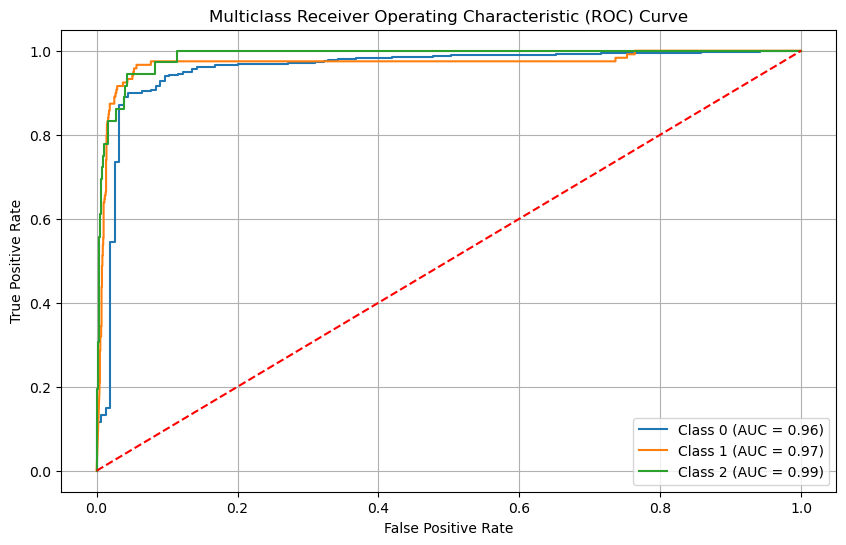

In [32]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


# multiclassification 
y_test_classes = label_binarize(y_test, classes=[0,1,2])

fpr ={}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_classes[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])


plt.figure(figsize=(10, 6))
for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

## Analyzing Coefficients 

In [34]:
feature_names = X_train.columns 
coef = best_model.named_steps['model'].coef_

In [35]:
# Place feature names in a dataframe
feat_df = pd.DataFrame(coef, columns= feature_names)
feat_df.index = ['neither','hypothyroid','hyperthyroid']
feat_df

,age,sex,FTI,T3,T4U,TSH,TT4,I131 treatment,goitre,hypopituitary,...,query on thyroxine,sick,thyroid surgery,tumor,FTI_missing,T3_missing,T4U_missing,TSH_missing,TT4_missing,sex_missing
neither,-0.193599,0.384149,-1.082909,-1.912416,0.506945,-18.364712,-0.529497,0.062635,0.782561,0.000000,...,0.011684,0.018941,1.527566,-0.350788,0.079910,-0.295378,-0.088045,-0.186464,1.315557,0.094347
hypothyroid,-0.019714,-0.385023,-1.427580,-0.825473,0.310419,21.946860,-0.170274,-0.400878,-0.800246,-0.104722,...,0.109695,-0.196245,-2.459895,-0.062069,0.195122,0.325855,-0.032755,-10.559561,-0.323054,-0.403196
hyperthyroid,-0.140664,-0.426543,1.390694,3.638720,-0.930270,-36.636575,1.417243,0.084718,-0.805014,0.047728,...,-0.353449,0.127174,-1.083201,0.570985,-0.671020,1.506026,0.684308,0.686327,-2.084647,0.396955


In [39]:
# convert to odds ratio 

odds_ratio = np.exp(coef)
odds_ratio_df = pd.DataFrame(odds_ratio, columns = feature_names)
odds_ratio_df.index = ['neither','hypothyroid','hyperthyroid']
odds_ratio_df

,age,sex,FTI,T3,T4U,TSH,TT4,I131 treatment,goitre,hypopituitary,...,query on thyroxine,sick,thyroid surgery,tumor,FTI_missing,T3_missing,T4U_missing,TSH_missing,TT4_missing,sex_missing
neither,0.823989,1.468365,0.338609,0.147723,1.660212,1.057565e-08,0.588901,1.064639,2.187067,1.000000,...,1.011753,1.019121,4.606952,0.704133,1.083190,0.744251,0.915720,0.829888,3.726826,1.098941
hypothyroid,0.980479,0.680435,0.239889,0.438028,1.363996,3.399383e+09,0.843433,0.669732,0.449219,0.900575,...,1.115938,0.821811,0.085444,0.939818,1.215460,1.385215,0.967776,0.000026,0.723935,0.668181
hyperthyroid,0.868781,0.652762,4.017639,38.043096,0.394447,1.227263e-16,4.125731,1.088410,0.447082,1.048885,...,0.702262,1.135615,0.338510,1.770010,0.511187,4.508778,1.982399,1.986406,0.124351,1.487289


In [42]:
#greatest to least odds ratio --- hypothyroid 
odds_df_sorted_hyper = odds_ratio_df.loc['hypothyroid'].sort_values(ascending=False)
odds_df_sorted_hyper

TSH                          3.399383e+09
T3_missing                   1.385215e+00
T4U                          1.363996e+00
query hyperthyroid           1.273602e+00
FTI_missing                  1.215460e+00
query on thyroxine           1.115938e+00
lithium                      1.060785e+00
query hypothyroid            1.060784e+00
age                          9.804794e-01
T4U_missing                  9.677757e-01
tumor                        9.398180e-01
hypopituitary                9.005751e-01
TT4                          8.434334e-01
sick                         8.218107e-01
psych                        7.295650e-01
TT4_missing                  7.239348e-01
sex                          6.804353e-01
I131 treatment               6.697316e-01
sex_missing                  6.681808e-01
goitre                       4.492185e-01
T3                           4.380277e-01
on antithyroid medication    2.668778e-01
FTI                          2.398887e-01
thyroid surgery              8.544

In [47]:
#greatest to least odds ratio --- hyperthyroid
odds_df_sorted_hypo = odds_ratio_df.loc['hyperthyroid'].sort_values(ascending=False)
odds_df_sorted_hypo

T3                           3.804310e+01
T3_missing                   4.508778e+00
TT4                          4.125731e+00
FTI                          4.017639e+00
query hyperthyroid           1.987101e+00
TSH_missing                  1.986406e+00
T4U_missing                  1.982399e+00
tumor                        1.770010e+00
sex_missing                  1.487289e+00
sick                         1.135615e+00
on antithyroid medication    1.090567e+00
I131 treatment               1.088410e+00
hypopituitary                1.048885e+00
age                          8.687812e-01
query hypothyroid            7.729742e-01
query on thyroxine           7.022616e-01
sex                          6.527615e-01
lithium                      6.144278e-01
FTI_missing                  5.111868e-01
goitre                       4.470818e-01
pregnant                     4.305438e-01
T4U                          3.944472e-01
thyroid surgery              3.385101e-01
psych                        1.623

In [46]:
#greatest to least odds ratio --- neither 
odds_df_sorted_neither = odds_ratio_df.loc['neither'].sort_values(ascending=False)
odds_df_sorted_neither

on thyroxine                 8.341542e+00
thyroid surgery              4.606952e+00
TT4_missing                  3.726826e+00
goitre                       2.187067e+00
T4U                          1.660212e+00
psych                        1.573439e+00
pregnant                     1.511028e+00
sex                          1.468365e+00
sex_missing                  1.098941e+00
FTI_missing                  1.083190e+00
I131 treatment               1.064639e+00
sick                         1.019121e+00
query on thyroxine           1.011753e+00
hypopituitary                1.000000e+00
on antithyroid medication    9.950878e-01
lithium                      9.795095e-01
query hypothyroid            9.385300e-01
T4U_missing                  9.157200e-01
TSH_missing                  8.298885e-01
age                          8.239886e-01
T3_missing                   7.442506e-01
tumor                        7.041331e-01
query hyperthyroid           6.582514e-01
TT4                          5.889

## Plotting Best Model Log Reg Odds Ratio 

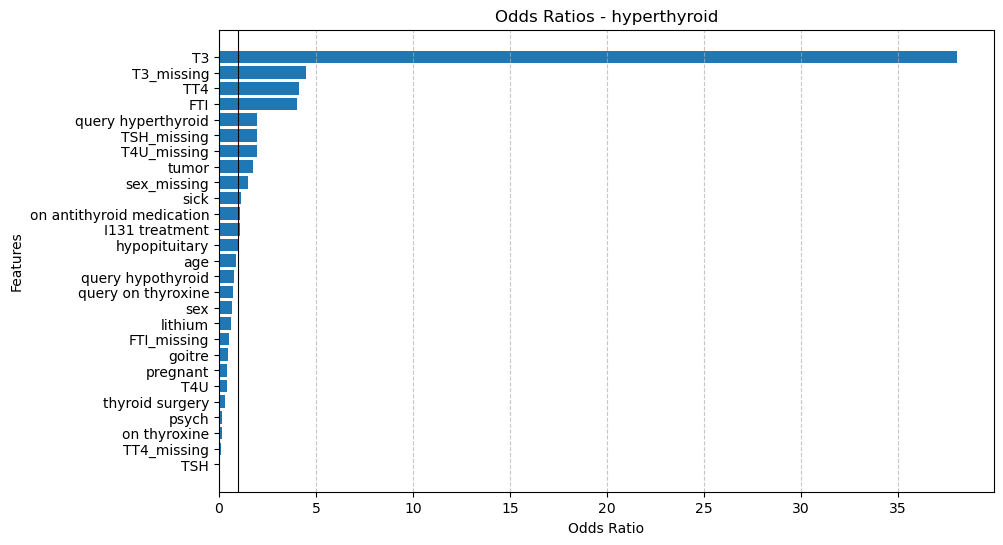

In [58]:
cls = 'hyperthyroid'
feat_odds = odds_ratio_df.loc[cls].sort_values(ascending=True)
        
plt.figure(figsize=(10, 6))
plt.barh(feat_odds.index, feat_odds.values)
plt.axvline(1, color='black', lw=0.8)  # 1 = no effect
plt.title(f'Odds Ratios - {cls}')
plt.xlabel('Odds Ratio')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


Based on the Odds Ratio graph, for every one unit increase in the T3 variable, the chances of having hyperthroidism increases slightly more than 35 times. 

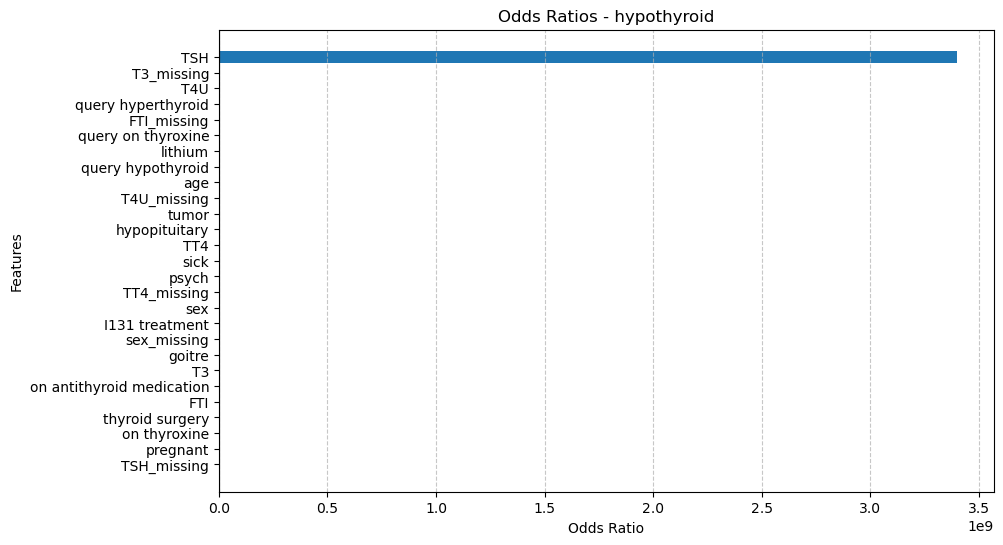

In [59]:
cls = 'hypothyroid'
feat_odds = odds_ratio_df.loc[cls].sort_values(ascending=True)
        
plt.figure(figsize=(10, 6))
plt.barh(feat_odds.index, feat_odds.values)
plt.axvline(1, color='black', lw=0.8)  # 1 = no effect
plt.title(f'Odds Ratios - {cls}')
plt.xlabel('Odds Ratio')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

For every one unit increase in the TSH variable, the chances of having hypothyroidism increases by about ~3.4 times. 

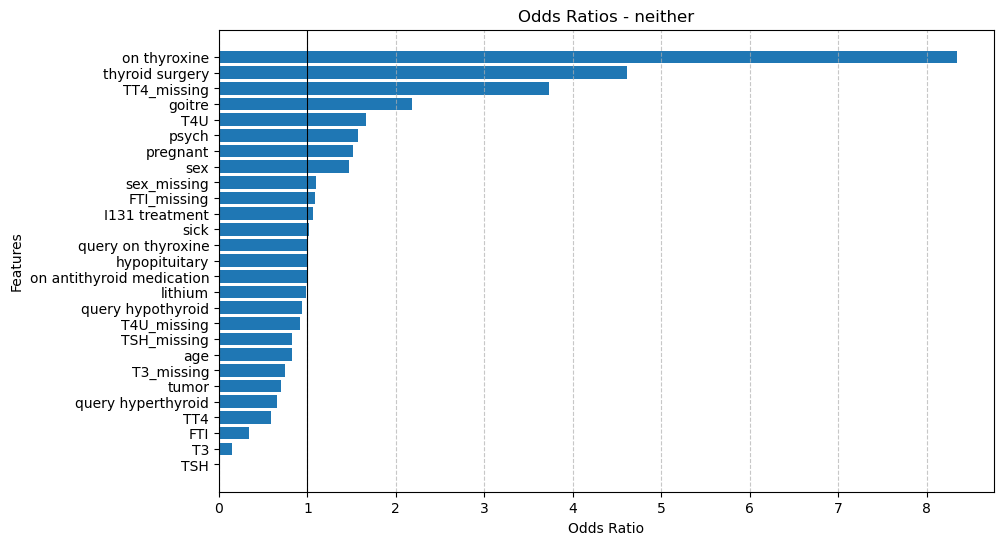

In [60]:
cls = 'neither'
feat_odds = odds_ratio_df.loc[cls].sort_values(ascending=True)
        
plt.figure(figsize=(10, 6))
plt.barh(feat_odds.index, feat_odds.values)
plt.axvline(1, color='black', lw=0.8)  # 1 = no effect
plt.title(f'Odds Ratios - {cls}')
plt.xlabel('Odds Ratio')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Correlations

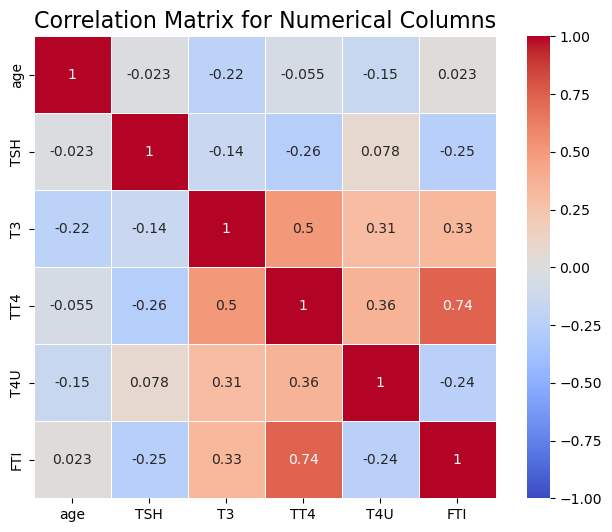

In [65]:
#numerical columns 

num_cols = ['age','TSH','T3','TT4','T4U','FTI']

correlation_matrix = thyroid_train[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, square=True)
plt.title('Correlation Matrix for Numerical Columns', fontsize=16)
plt.show()